# 🔍 03 — Detecção de Hotspots e Diagnóstico Normativo de Falhas (NBR 15572 / NFPA 70B)

Neste notebook demonstramos a estratégia de diagnóstico preditivo industrial combinando:
1. **Identificação Semântica do Ativo via DINOv2:** Classifica o tipo de equipamento elétrico em alta tensão.
2. **Detecção Geométrica de Ponto Quente (*Hotspot*):** Localiza pixel de pico térmico e bounding box da anomalia em imagens RGB.
3. **Motor Normativo NBR 15572 / NFPA 70B:** Converte a elevação térmica em diagnósticos de severidade (*Normal, Atenção, Grave, Crítico*) e emite ordens de ação de manutenção preventiva/corretiva.

---
## 1. Importação de Dependências e Configuração

In [1]:
from pathlib import Path
import sys
import cv2
import matplotlib.pyplot as plt

# Adiciona a pasta raiz ao path
sys.path.insert(0, str(Path.cwd().parent))

from src.industrial_analyzer import IndustrialThermalAnalyzer
from src.hotspot_detector import HotspotDetector
from src.normative_rules import NormativeThermalEngine, SeverityLevel

print("Módulos industriais carregados com sucesso!")

Módulos industriais carregados com sucesso!


---
## 2. Inicialização do Analisador Industrial

Carrega o modelo treinado DINOv2 e conecta o detector de hotspots e motor normativo.

In [2]:
model_path = Path("../outputs/models/classifier_dinov2.pkl")
analyzer = IndustrialThermalAnalyzer(model_path=model_path)
print(f"Analisador pronto! Classes monitoradas: {analyzer.classes}")

CUDA solicitado mas indisponível. Usando CPU.


Using cache found in C:\Users\gabri/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\gabri/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\gabri/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\gabri/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Analisador pronto! Classes monitoradas: ['Circuit Breakers', 'Disconnectors', 'Power Transformers', 'Surge Arresters', 'Wave Traps']


---
## 3. Inspeção Individual Detalhada com Overlay Gráfico

             RELATÓRIO DE INSPEÇÃO TÉRMICA
Equipamento Identificado : Power Transformers
Confiança DINOv2         : 99.93%
Coordenada do Hotspot    : X=537, Y=372
Região Crítica (BBox)    : (442, 283, 198, 197)
Elevação Térmica Est.    : +38.4 °C
Severidade NBR 15572     : Grave (Ação Programada)
Ação Recomendada         : [Power Transformers] Aquecimento significativo. Risco de degradação acelerada de isoladores e contatos. Programar intervenção corretiva em até 48 horas e monitorar corrente de carga.


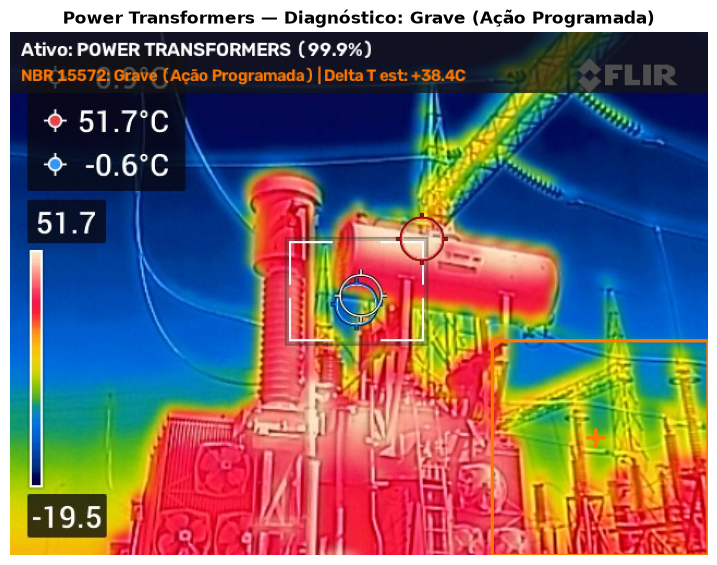

In [3]:
# Selecione qualquer imagem do dataset bruto para inspecionar
sample_image = Path("../data/raw/Power Transformers/FLIR0150.jpg")

report = analyzer.inspect_image(sample_image)

print("=" * 60)
print("             RELATÓRIO DE INSPEÇÃO TÉRMICA")
print("=" * 60)
print(f"Equipamento Identificado : {report.equipment_class}")
print(f"Confiança DINOv2         : {report.classification_confidence*100:.2f}%")
print(f"Coordenada do Hotspot    : X={report.hotspot.peak_coordinate[0]}, Y={report.hotspot.peak_coordinate[1]}")
print(f"Região Crítica (BBox)    : {report.hotspot.bounding_box}")
print(f"Elevação Térmica Est.    : +{report.diagnosis.delta_t_celsius:.1f} °C")
print(f"Severidade NBR 15572     : {report.diagnosis.severity.value}")
print(f"Ação Recomendada         : {report.diagnosis.recommended_action}")
print("=" * 60)

# Exibição gráfica da imagem anotada
plt.figure(figsize=(9, 7))
annotated_rgb = cv2.cvtColor(report.annotated_image, cv2.COLOR_BGR2RGB)
plt.imshow(annotated_rgb)
plt.title(f"{report.equipment_class} — Diagnóstico: {report.diagnosis.severity.value}", fontsize=12, fontweight="bold")
plt.axis("off")
plt.show()

---
## 4. Inspeção Comparativa Multi-Ativos

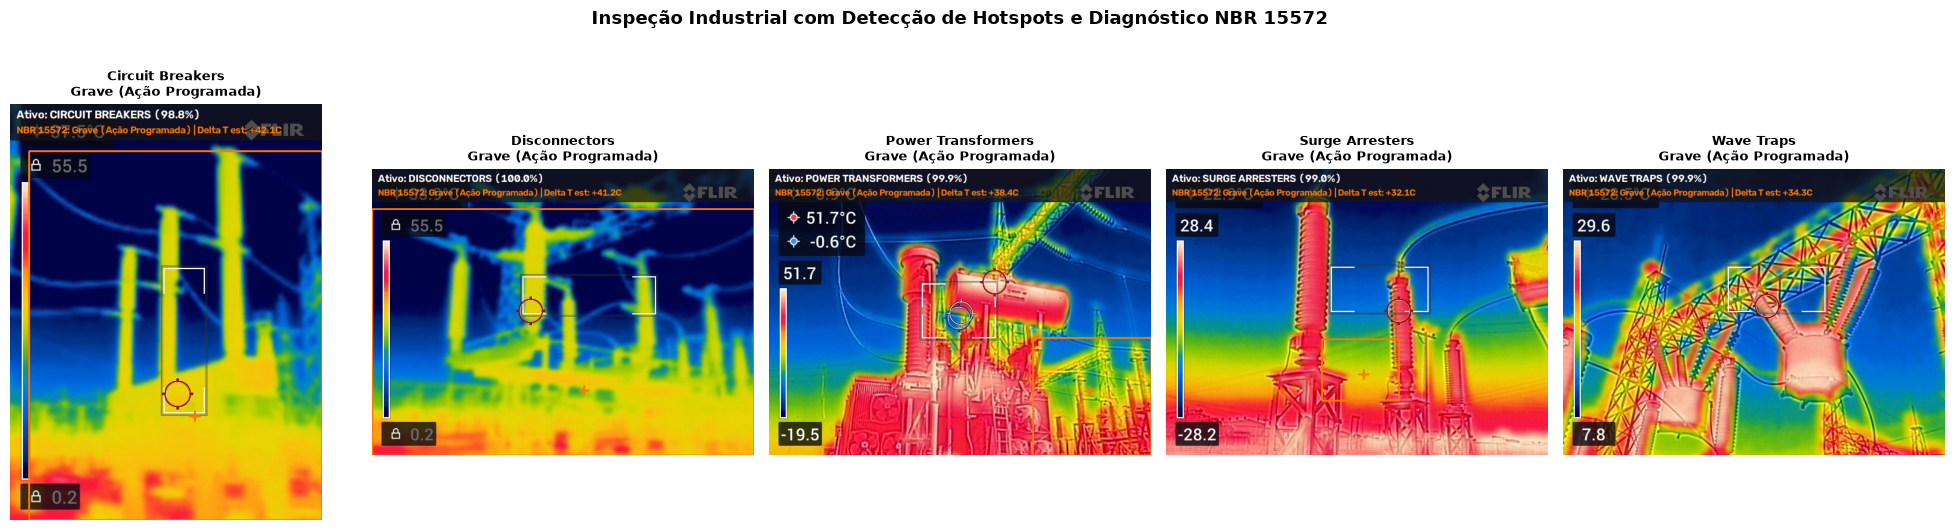

In [4]:
sample_assets = [
    Path("../data/raw/Circuit Breakers/FLIR2296.jpg"),
    Path("../data/raw/Disconnectors/FLIR2284.jpg"),
    Path("../data/raw/Power Transformers/FLIR0150.jpg"),
    Path("../data/raw/Surge Arresters/FLIR2572.jpg"),
    Path("../data/raw/Wave Traps/FLIR2556.jpg"),
]

fig, axes = plt.subplots(1, len(sample_assets), figsize=(20, 5))

for i, asset_path in enumerate(sample_assets):
    rep = analyzer.inspect_image(asset_path)
    img_rgb = cv2.cvtColor(rep.annotated_image, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_rgb)
    axes[i].set_title(f"{rep.equipment_class}\n{rep.diagnosis.severity.value}", fontsize=9, fontweight="bold")
    axes[i].axis("off")

plt.suptitle("Inspeção Industrial com Detecção de Hotspots e Diagnóstico NBR 15572", fontsize=13, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()